In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load cleaned property sales data
df = pd.read_csv(
    "../data/processed/property_sales_clean.csv"
)

df.head()

,borough,neighborhood,building_class_category,tax_class_at_present,block,lot,building_class_at_present,address,zip_code,residential_units,...,tax_class_at_time_of_sale,building_class_at_time_of,sale_price,sale_date,apartment_number,price_per_sqft,sale_year,sale_month,sale_quarter,property_age
0,Manhattan,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376,41,C6,"745 EAST 6TH STREET, 1B",10009.0,28.0,...,2,C4,540000,2025-12-17,NaN,29.582557,2025,12,4,125.0
1,Manhattan,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,377,50,C2,"275 EAST 7TH STREET, 3",10009.0,5.0,...,2,C2,1250000,2026-05-27,NaN,198.601843,2026,5,2,126.0
2,Manhattan,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,389,22,C7,208 EAST 7TH STREET,10009.0,28.0,...,2,C7,8600000,2026-03-09,NaN,442.888042,2026,3,1,126.0
3,Manhattan,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,390,60,C2,191 EAST 7 STREET,10009.0,5.0,...,2,C2,4665000,2026-03-25,NaN,1401.742788,2026,3,1,116.0
4,Manhattan,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,392,34,C7,153 AVENUE C,10009.0,8.0,...,2,C7,6850000,2026-05-14,NaN,1096.877502,2026,5,2,75.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52595 entries, 0 to 52594
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   borough                    52595 non-null  str    
 1   neighborhood               52595 non-null  str    
 2   building_class_category    52595 non-null  str    
 3   tax_class_at_present       52595 non-null  str    
 4   block                      52595 non-null  int64  
 5   lot                        52595 non-null  int64  
 6   building_class_at_present  52595 non-null  str    
 7   address                    52594 non-null  str    
 8   zip_code                   52582 non-null  float64
 9   residential_units          36346 non-null  float64
 10  commercial_units           25795 non-null  float64
 11  total_units                38684 non-null  float64
 12  land_square_feet           329 non-null    float64
 13  gross_square_feet          22443 non-null  float64
 14  y

In [4]:
# Convert sale date back to datetime
df["sale_date"] = pd.to_datetime(df["sale_date"])

In [5]:
df.shape

(52595, 25)

In [6]:
# Summary statistics for sale prices
df["sale_price"].describe()

count    5.259500e+04
mean     3.298061e+06
std      1.665938e+07
min      1.000000e+03
25%      5.750000e+05
50%      9.200000e+05
75%      1.685000e+06
max      5.722903e+08
Name: sale_price, dtype: float64

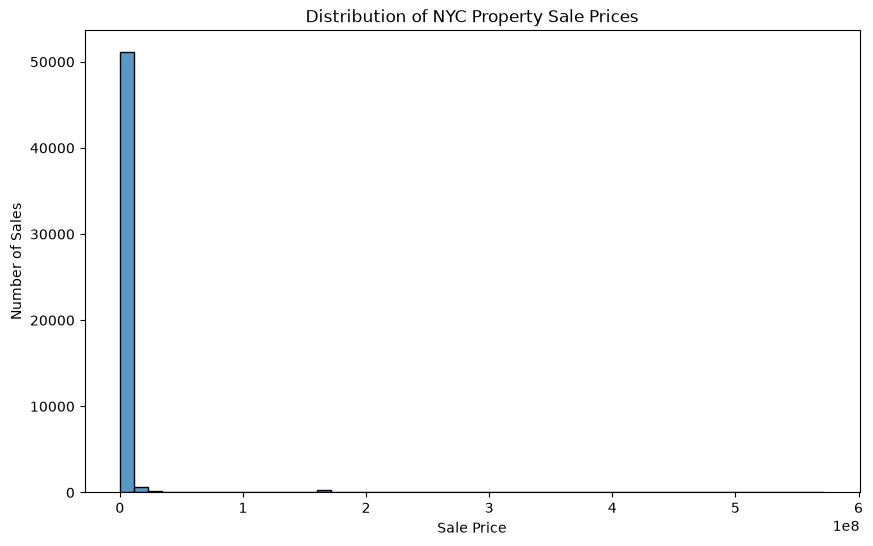

In [11]:
# Distribution of property sale prices
plt.figure(figsize=(10, 6))

sns.histplot(data=df,x="sale_price",bins=50)
plt.title("Distribution of NYC Property Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Sales")

plt.show()

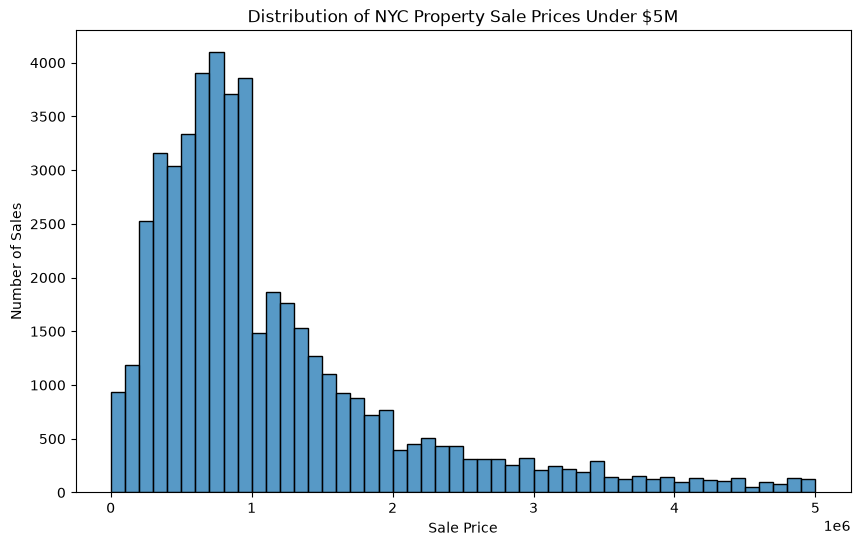

In [ ]:
# Distribution of typical property sale prices
typical_sales = df[df["sale_price"] <= 5000000]
plt.figure(figsize=(10, 6))

sns.histplot(data=typical_sales,x="sale_price",bins=50)

plt.title("Distribution of NYC Property Sale Prices Under $5M")
plt.xlabel("Sale Price")
plt.ylabel("Number of Sales")

plt.show()

Finding: NYC property sale prices are strongly right-skewed. The median sale price is approximately $920K, while the mean is approximately $3.3M, indicating that a smaller number of very expensive transactions pull the average upward.

In [13]:
# Summarize sales by borough
borough_summary = (
    df.groupby("borough")
    .agg(
        total_sales=("sale_price", "count"),
        median_sale_price=("sale_price", "median")
    )
    .sort_values("total_sales", ascending=False)
)

borough_summary

,total_sales,median_sale_price
borough,,
Queens,15736,777000.0
Manhattan,15069,1387500.0
Brooklyn,13661,1127575.0
Staten Island,4170,733070.0
Bronx,3959,700000.0


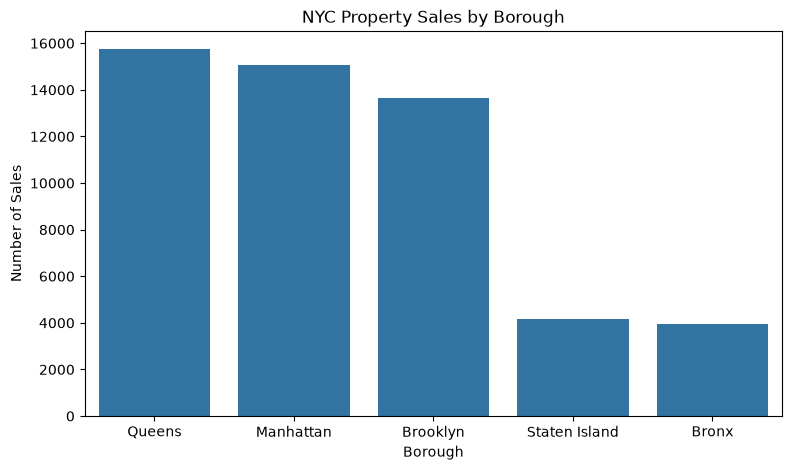

In [14]:
# Property sales by borough
plt.figure(figsize=(9, 5))

sns.barplot(data=borough_summary.reset_index(),x="borough",y="total_sales")

plt.title("NYC Property Sales by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Sales")

plt.show()

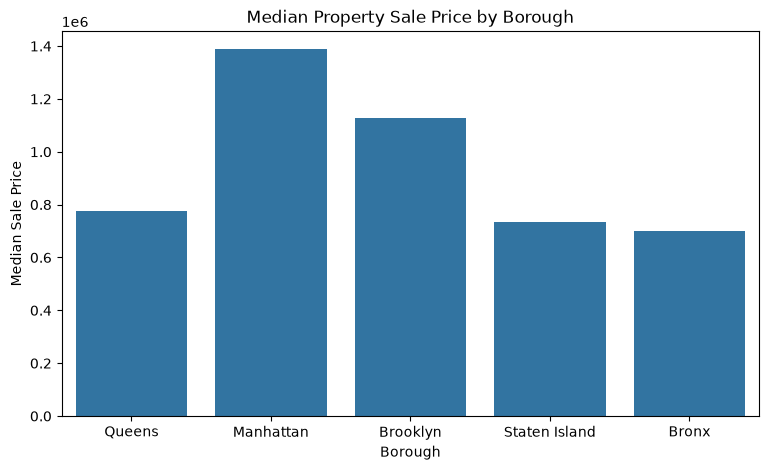

In [15]:
# Median sale price by borough
plt.figure(figsize=(9, 5))

sns.barplot(data=borough_summary.reset_index(),x="borough",y="median_sale_price")

plt.title("Median Property Sale Price by Borough")
plt.xlabel("Borough")
plt.ylabel("Median Sale Price")

plt.show()

Finding: Queens had the most property sales with 15,736 transactions, while Manhattan had the highest median sale price at approximately $1.39M. The Bronx had the lowest median sale price at $700K.

In [16]:
# Find the top 10 neighborhoods by number of sales
top_neighborhoods = (
    df.groupby("neighborhood")
    .size()
    .reset_index(name="total_sales")
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_neighborhoods

,neighborhood,total_sales
86,FLUSHING-NORTH,2360
226,UPPER EAST SIDE (59-79),1646
227,UPPER EAST SIDE (79-96),1401
229,UPPER WEST SIDE (59-79),1258
149,MIDTOWN EAST,1043
230,UPPER WEST SIDE (79-96),897
89,FOREST HILLS,831
8,ASTORIA,756
15,BEDFORD STUYVESANT,733
40,CHELSEA,708


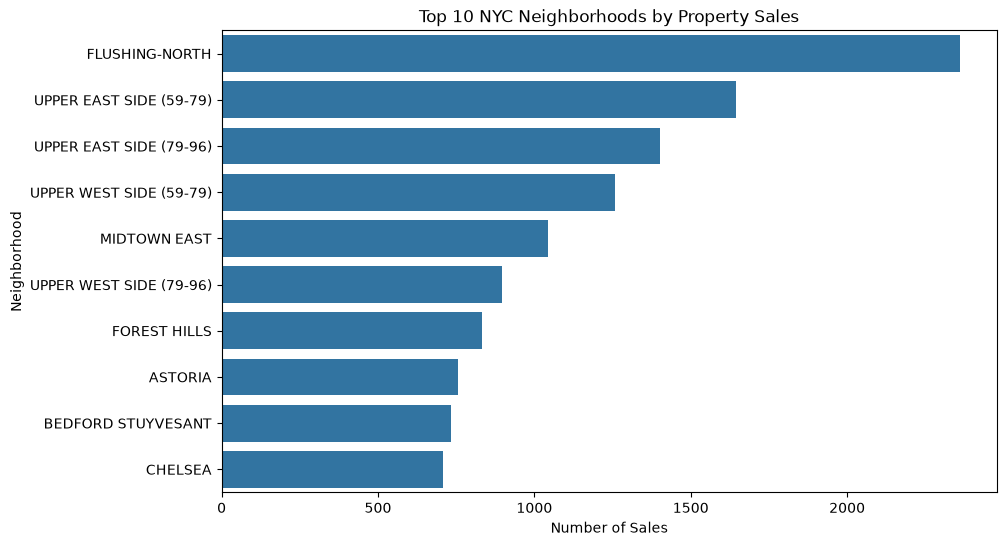

In [17]:
# Top 10 neighborhoods by property sales
plt.figure(figsize=(10, 6))

sns.barplot( data=top_neighborhoods,x="total_sales",y="neighborhood")

plt.title("Top 10 NYC Neighborhoods by Property Sales")
plt.xlabel("Number of Sales")
plt.ylabel("Neighborhood")

plt.show()

Finding: Flushing-North had the highest sales activity with 2,360 transactions, followed by the Upper East Side (59–79) with 1,646. Several Manhattan neighborhoods also appear among the top 10 most active neighborhoods.

In [18]:
# Find the top 10 property types by number of sales
top_property_types = (
    df.groupby("building_class_category")
    .size()
    .reset_index(name="total_sales")
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_property_types

,building_class_category,total_sales
9,10 COOPS - ELEVATOR APARTMENTS,10635
12,13 CONDOS - ELEVATOR APARTMENTS,9962
0,01 ONE FAMILY DWELLINGS,9581
1,02 TWO FAMILY DWELLINGS,7170
8,09 COOPS - WALKUP APARTMENTS,2041
2,03 THREE FAMILY DWELLINGS,1876
6,07 RENTALS - WALKUP APARTMENTS,1584
14,15 CONDOS - 2-10 UNIT RESIDENTIAL,1263
16,17 CONDO COOPS,1142
38,44 CONDO PARKING,1062


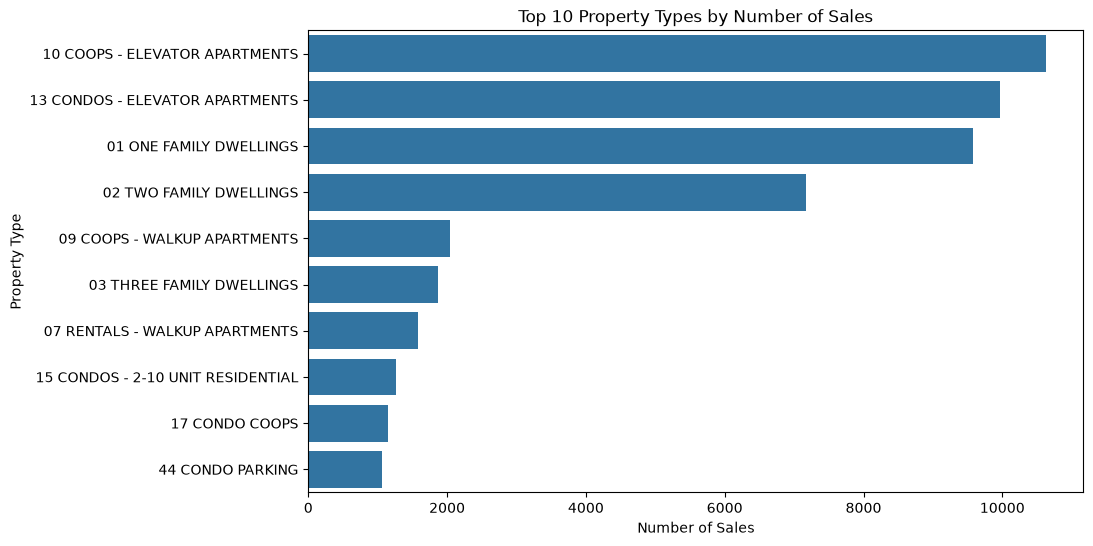

In [19]:
# Top 10 property types by number of sales
plt.figure(figsize=(10, 6))

sns.barplot(data=top_property_types,x="total_sales",y="building_class_category")

plt.title("Top 10 Property Types by Number of Sales")
plt.xlabel("Number of Sales")
plt.ylabel("Property Type")

plt.show()

Finding: Elevator co-ops were the most common property type with 10,635 sales, followed closely by elevator condos with 9,962 and one-family dwellings with 9,581. These three categories accounted for much of the sales activity in the dataset.

In [20]:
# Create year-month for time analysis
df["year_month"] = df["sale_date"].dt.to_period("M").astype(str)

# Count sales by month
monthly_sales = (
    df.groupby("year_month")
    .size()
    .reset_index(name="total_sales")
)

monthly_sales

,year_month,total_sales
0,2025-09,4724
1,2025-10,4833
2,2025-11,3864
3,2025-12,4836
4,2026-01,4279
5,2026-02,3657
6,2026-03,4581
7,2026-04,3947
8,2026-05,4116
9,2026-06,5008


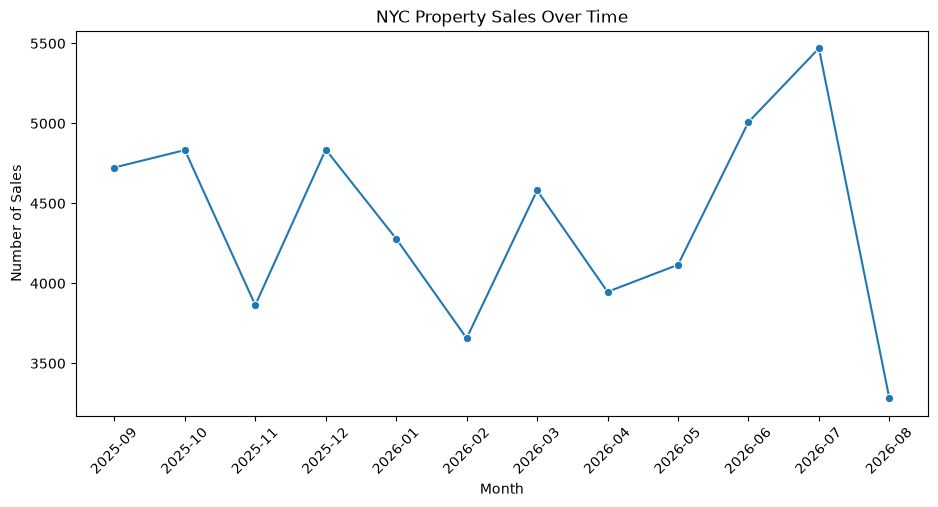

In [21]:
# Property sales over time
plt.figure(figsize=(11, 5))

sns.lineplot(data=monthly_sales,x="year_month",y="total_sales",marker="o")

plt.title("NYC Property Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)

plt.show()

Finding: Monthly sales fluctuated throughout the year, reaching their highest level in July 2026 with 5,469 sales. The lower August 2026 count may reflect an incomplete month of data, so it should be interpreted cautiously.

In [22]:
# Calculate median price per square foot by borough
borough_price_sqft = (
    df.groupby("borough")["price_per_sqft"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

borough_price_sqft

,borough,price_per_sqft
0,Manhattan,702.932844
1,Brooklyn,576.662144
2,Queens,562.330623
3,Staten Island,474.285714
4,Bronx,376.524617


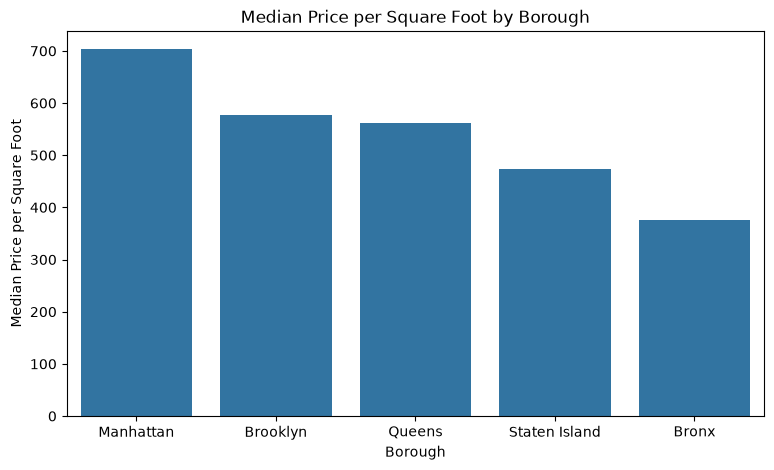

In [23]:
# Median price per square foot by borough
plt.figure(figsize=(9, 5))

sns.barplot(data=borough_price_sqft,x="borough",y="price_per_sqft")

plt.title("Median Price per Square Foot by Borough")
plt.xlabel("Borough")
plt.ylabel("Median Price per Square Foot")

plt.show()

Finding: Manhattan had the highest median price per square foot at approximately $703, followed by Brooklyn at $577 and Queens at $562. The Bronx had the lowest median at approximately $377 per square foot.